# 04 · Walk-Forward Models — Quick Test & Validation
**Script chính:** `scripts/run_models.py`  
**Notebook này:** Load predictions + walkforward results → kiểm tra AUC, ensemble, predictions distribution.

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.utils.io import load

cfg = load_config(ROOT / 'configs' / 'base.yaml')

## 1. Load Walk-Forward Results

In [2]:
wf_full = pd.read_csv(cfg.dir_outputs / 'metrics' / 'walkforward_full.csv')

print(f"Walk-forward Full: {len(wf_full)} fold-model rows")
print(f"Folds: {sorted(wf_full['test_year'].unique())}")
print(f"Models: {sorted(wf_full['model'].unique())}")

n_folds = wf_full['test_year'].nunique()
n_models = wf_full['model'].nunique()
assert n_folds >= 5, f"Too few folds: {n_folds}"
assert n_models == 3, f"Expected 3 models, got {n_models}"
print(f"\nOK: {n_folds} folds x {n_models} models")

Walk-forward Full: 21 fold-model rows
Folds: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Models: ['LGBM', 'LR', 'RF']

OK: 7 folds x 3 models


## 2. AUC per Fold — ML Full

=== AUC: ML Full ===
model       LGBM     LR     RF
test_year                     
2020       0.538  0.520  0.537
2021       0.490  0.530  0.512
2022       0.470  0.514  0.474
2023       0.517  0.550  0.510
2024       0.471  0.523  0.481
2025       0.575  0.477  0.544
2026       0.380  0.284  0.486

Test size per fold: {2020: np.int64(16524), 2021: np.int64(16456), 2022: np.int64(16388), 2023: np.int64(16320), 2024: np.int64(16456), 2025: np.int64(16320), 2026: np.int64(1904)}


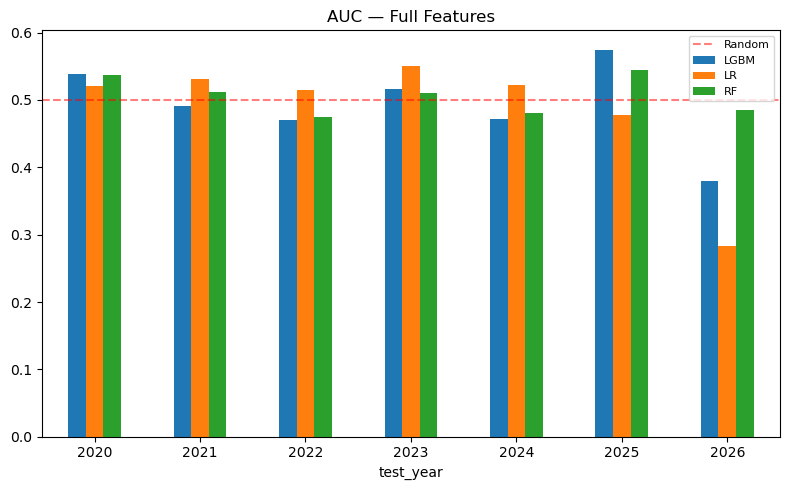


--- Avg AUC (ALL 7 folds, kể cả partial): 0.494 ---
--- Avg AUC (6 folds đầy đủ [2020, 2021, 2022, 2023, 2024, 2025]): 0.513 ---
--- Partial folds (test_size < 50% median): [2026] ---
    Đề nghị dùng số 'full years' để báo cáo, partial year không đại diện.

OK: Models show predictive signal trên full years


In [3]:
print("=== AUC: ML Full ===")
pivot_full = wf_full.pivot_table(index='test_year', columns='model', values='daily_auc')
print(pivot_full.round(3).to_string())

# Test_size per fold — fold cuối thường partial year
size_per_fold = wf_full.groupby('test_year')['test_size'].first()
print(f"\nTest size per fold: {dict(size_per_fold)}")

fig, ax = plt.subplots(figsize=(8, 5))
pivot_full.plot(kind='bar', ax=ax, title='AUC — Full Features', rot=0)
ax.axhline(0.5, ls='--', color='red', alpha=0.5, label='Random')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# IMPORTANT: 2 cách tính trung bình AUC.
# Fold cuối (vd 2026) có thể là partial year (test_size << các fold khác) → kéo trung bình lệch.
# Show CẢ HAI số để minh bạch.
PARTIAL_THRESHOLD = 0.5  # fold nào có test_size < 50% median được coi là partial
median_size = size_per_fold.median()
full_year_folds = size_per_fold[size_per_fold >= PARTIAL_THRESHOLD * median_size].index.tolist()
partial_folds = size_per_fold[size_per_fold < PARTIAL_THRESHOLD * median_size].index.tolist()

avg_auc_all = pivot_full.mean().mean()
avg_auc_full_years = pivot_full.loc[full_year_folds].mean().mean()

print(f"\n--- Avg AUC (ALL {len(pivot_full)} folds, kể cả partial): {avg_auc_all:.3f} ---")
print(f"--- Avg AUC ({len(full_year_folds)} folds đầy đủ {full_year_folds}): {avg_auc_full_years:.3f} ---")
if partial_folds:
    print(f"--- Partial folds (test_size < {PARTIAL_THRESHOLD*100:.0f}% median): {partial_folds} ---")
    print(f"    Đề nghị dùng số 'full years' để báo cáo, partial year không đại diện.")

assert avg_auc_full_years > 0.50, f"Avg AUC trên full years quá thấp: {avg_auc_full_years:.3f}"
print("\nOK: Models show predictive signal trên full years")

avg_auc = avg_auc_full_years  # dùng số full-years cho summary cuối

## 3. Ensemble Predictions Validation

In [4]:
ens_full = load(cfg.dir_processed / 'predictions_ens_full.parquet')

print(f"Ensemble Full: {len(ens_full):,} rows")

# Check y_prob in [0, 1]
assert (ens_full['y_prob'] >= 0).all() and (ens_full['y_prob'] <= 1).all(), "y_prob out of [0,1]"

# Check no NaN in y_prob
assert ens_full['y_prob'].notna().all(), "NaN in full ensemble y_prob"

# Check ensemble covers all test years
ens_years = sorted(ens_full.index.get_level_values('date').year.unique())
print(f"Ensemble years: {ens_years}")
assert ens_years[0] == cfg.walkforward.first_test_year, "First test year mismatch"

print(f"\ny_prob stats (Full):")
print(ens_full['y_prob'].describe().round(4).to_string())
print("\nOK: Ensemble predictions valid")

Ensemble Full: 100,368 rows
Ensemble years: [2020, 2021, 2022, 2023, 2024, 2025, 2026]

y_prob stats (Full):
count    100368.0000
mean          0.5018
std           0.0938
min           0.1141
25%           0.4536
50%           0.5043
75%           0.5511
max           0.8890

OK: Ensemble predictions valid


## 3b. Data Inspection — nhìn thẳng vào predictions

In `head/describe` của ensemble predictions + walkforward AUC raw + top-10 dự đoán cho ngày cuối cùng để xác nhận shape, range, và logic.

In [5]:
print("--- wf_full.head(10) — walkforward AUC raw ---")
print(wf_full.head(10).round(4).to_string())

print("\n--- wf_full.describe() ---")
print(wf_full.describe().round(4).to_string())

print("\n--- ens_full.head(15) — ensemble predictions ---")
print(ens_full.head(15).round(4).to_string())

print("\n--- ens_full.tail(5) ---")
print(ens_full.tail(5).round(4).to_string())

print("\n--- ens_full columns:", list(ens_full.columns), "---")
print(f"--- ens_full memory: {ens_full.memory_usage(deep=True).sum() / 1e6:.2f} MB ---")

print("\n--- TOP-10 predictions on last available date ---")
last_date = ens_full.index.get_level_values('date').max()
top10 = ens_full.loc[last_date].sort_values('y_prob', ascending=False).head(10)
print(f"Date: {last_date.date()}")
print(top10.round(4).to_string())

print("\n--- BOTTOM-10 predictions on last available date ---")
bot10 = ens_full.loc[last_date].sort_values('y_prob').head(10)
print(bot10.round(4).to_string())

print("\n--- Sample: AAPL predictions over time (every 250th row) ---")
aapl_pred = ens_full.xs('AAPL', level='ticker', drop_level=False).iloc[::250]
print(aapl_pred.round(4).to_string())

--- wf_full.head(10) — walkforward AUC raw ---
   fold  test_year model  global_auc  daily_auc  top_k_ret  rank_corr  train_size  test_size
0     1       2020    LR      0.5265     0.5204     0.0143     0.0310       26043      16524
1     1       2020    RF      0.5355     0.5371     0.0173     0.0485       26043      16524
2     1       2020  LGBM      0.5392     0.5384     0.0168     0.0478       68062      16524
3     2       2021    LR      0.5454     0.5303     0.0069     0.0260       32645      16456
4     2       2021    RF      0.5225     0.5124     0.0038     0.0169       32645      16456
5     2       2021  LGBM      0.4915     0.4903     0.0026    -0.0170       85350      16456
6     3       2022    LR      0.5245     0.5145    -0.0040     0.0148       39139      16388
7     3       2022    RF      0.4889     0.4743    -0.0009    -0.0299       39139      16388
8     3       2022  LGBM      0.4726     0.4698    -0.0070    -0.0415      102360      16388
9     4       2023    L

## 4. Prediction Distribution

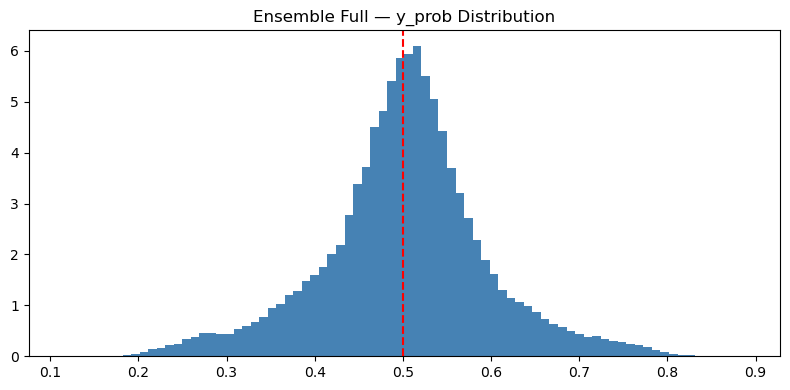

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ens_full['y_prob'], bins=80, color='steelblue', edgecolor='none', density=True)
ax.axvline(0.5, ls='--', color='red')
ax.set_title('Ensemble Full — y_prob Distribution')
plt.tight_layout()
plt.show()

## 5. Individual Model Predictions (if available)

In [7]:
pred_all_path = cfg.dir_processed / 'predictions_all_full.parquet'
if pred_all_path.exists():
    pred_all = load(pred_all_path)
    models = sorted(pred_all['model'].unique())
    print(f"Individual models: {models}")
    print(f"Total predictions: {len(pred_all):,}")
    
    for m in models:
        sub = pred_all[pred_all['model'] == m]['y_prob']
        print(f"  {m}: mean={sub.mean():.3f}, std={sub.std():.3f}, "
              f"[{sub.min():.3f}, {sub.max():.3f}]")
else:
    print("SKIP: predictions_all_full.parquet not found")

Individual models: ['LGBM', 'LR', 'RF']
Total predictions: 301,104
  LGBM: mean=0.507, std=0.288, [0.015, 1.000]
  LR: mean=0.508, std=0.077, [0.086, 0.951]
  RF: mean=0.495, std=0.046, [0.296, 0.717]


## 6. Calibration check — predicted vs realized positive rate

A well-calibrated classifier should have realized positive rate ≈ predicted prob across bins. Strong miscalibration suggests the model ranks well but emits unreliable probabilities (which still works for top-K selection but breaks confidence-weighting).

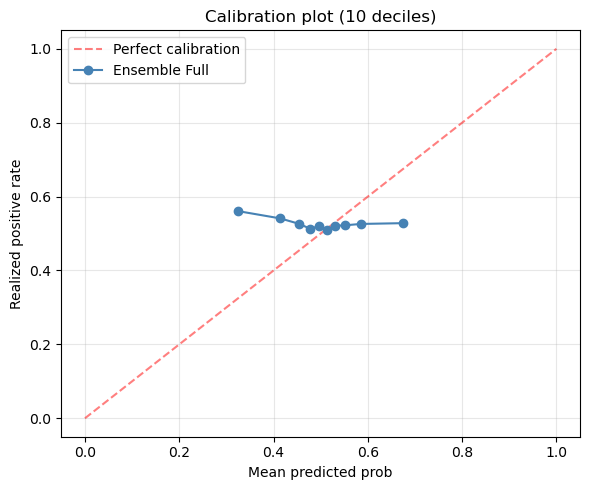

    pred  realized     n
0.323945  0.560825 10037
0.414065  0.540998 10037
0.453298  0.526552 10037
0.477049  0.513452 10036
0.495825  0.519279 10037
0.512620  0.510411 10037
0.530033  0.520825 10036
0.551628  0.522268 10037
0.585331  0.525954 10037
0.674390  0.528046 10037


In [8]:
lab_path = cfg.dir_processed / 'dataset_labeled.parquet'
if lab_path.exists() and 'tb_label' in (lab_cols := load(lab_path).columns):
    lab = load(lab_path)[['tb_label']]
    merged = ens_full.join(lab, how='inner').dropna(subset=['y_prob','tb_label'])
    merged['bin'] = pd.qcut(merged['y_prob'], q=10, duplicates='drop')
    cal = merged.groupby('bin', observed=True).agg(
        pred=('y_prob', 'mean'), realized=('tb_label', 'mean'), n=('tb_label', 'size')
    ).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0,1],[0,1], '--', color='red', alpha=0.5, label='Perfect calibration')
    ax.plot(cal['pred'], cal['realized'], 'o-', color='steelblue', label='Ensemble Full')
    ax.set_xlabel('Mean predicted prob'); ax.set_ylabel('Realized positive rate')
    ax.set_title('Calibration plot (10 deciles)'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print(cal.to_string(index=False))
else:
    print('SKIP: dataset_labeled.parquet missing — run scripts/run_labeling.py first.')

## 7. Per-model AUC distribution side-by-side

Which base model carries the ensemble? Compare AUC stability across folds.

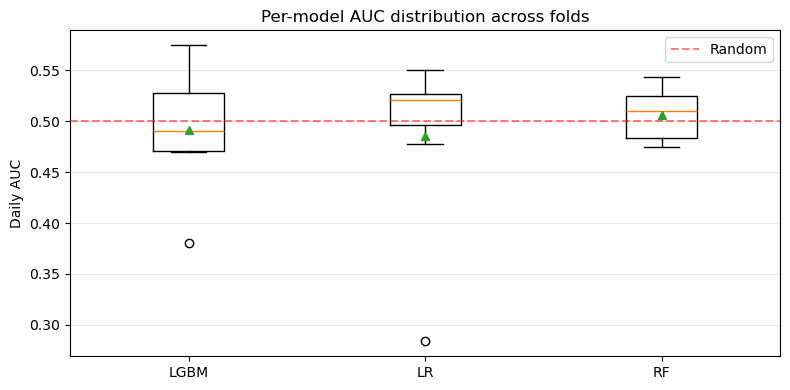

        mean    std    min    max
model                            
LGBM   0.492  0.062  0.380  0.575
LR     0.486  0.092  0.284  0.550
RF     0.506  0.027  0.474  0.544


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
models = sorted(wf_full['model'].unique())
data = [wf_full[wf_full['model']==m]['daily_auc'].values for m in models]
ax.boxplot(data, labels=models, showmeans=True)
ax.axhline(0.5, ls='--', color='red', alpha=0.5, label='Random')
ax.set_title('Per-model AUC distribution across folds'); ax.set_ylabel('Daily AUC'); ax.legend()
ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()
print(wf_full.groupby('model')['daily_auc'].agg(['mean','std','min','max']).round(3))

In [10]:
print("=" * 50)
print("04_models: ALL CHECKS PASSED")
print(f"  Folds: {n_folds}, Models: {n_models}")
print(f"  Avg AUC ALL folds: {avg_auc_all:.3f}  (kéo lệch bởi partial fold)")
print(f"  Avg AUC FULL years ({len(full_year_folds)}): {avg_auc:.3f}  ← reportable number")
print(f"  Ensemble Full: {len(ens_full):,} predictions")
print("=" * 50)

04_models: ALL CHECKS PASSED
  Folds: 7, Models: 3
  Avg AUC ALL folds: 0.494  (kéo lệch bởi partial fold)
  Avg AUC FULL years (6): 0.513  ← reportable number
  Ensemble Full: 100,368 predictions
